# Simple EDA


## Task: Trick classification


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
MANIFEST_DIR = DATA_DIR / "manifests"
TASK_MANIFEST_DIR = MANIFEST_DIR / "trick_classification"
CLIPS_DIR = DATA_DIR / "clips"
TRICK_TASK_COLUMNS = ["trick", "execution_score", "key_foot", "person"]
SCORE_TASK_COLUMNS = ["execution_score", "trick", "key_foot", "person"]

### Load manifests


In [2]:
split_paths = {
    "train": TASK_MANIFEST_DIR / "train.jsonl",
    "val": TASK_MANIFEST_DIR / "val.jsonl",
    "test": TASK_MANIFEST_DIR / "test.jsonl",
}
split_frames = {}
for split, path in split_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing manifest: {path}. Run the data pipeline first."
        )
    df = pd.read_json(path, lines=True)
    df["split"] = split
    split_frames[split] = df

manifest_df = pd.concat(split_frames.values(), ignore_index=True)
print("Manifest rows per split:")
for split, df in split_frames.items():
    print(f"  {split}: {len(df)}")
manifest_df.head()

Manifest rows per split:
  train: 455
  val: 58
  test: 57


video_id  \
0  25-11-15 18-42-16 5731-00.13.38.965-00.13.43.2...   
1  25-11-15 18-42-16 5731-00.09.06.455-00.09.11.2...   
2  25-11-15 18-42-16 5731-00.09.54.221-00.09.58.2...   
3  25-11-02 19-14-55 5695-00.13.05.773-00.13.11.4...   
4  25-11-17 21-54-30 5744-00.05.24.637-00.05.30.7...   

                                             s3_path     trick key_foot  \
0  s3://aitraf/clips/25-11-15 18-42-16 5731-00.13...  top-soul    right   
1  s3://aitraf/clips/25-11-15 18-42-16 5731-00.09...     mizou     left   
2  s3://aitraf/clips/25-11-15 18-42-16 5731-00.09...  top-soul     left   
3  s3://aitraf/clips/25-11-02 19-14-55 5695-00.13...     mizou     left   
4  s3://aitraf/clips/25-11-17 21-54-30 5744-00.05...  top-soul     left   

     person  execution_score  \
0       Max             0.75   
1  Henrikas             0.25   
2  Henrikas             0.75   
3  Henrikas             0.75   
4  Henrikas             1.00   

0  Form - really good. Just a bit too slow and short  train  
1     Very sketchy landing, almost counts as landed.  train  
2  A bit too short, not low enough, but i just li...  train  
3       Position could be lower, and not long enough  train  
4  A bit too slow, and landing not perfect, but s...  train

### Feature distribution across splits


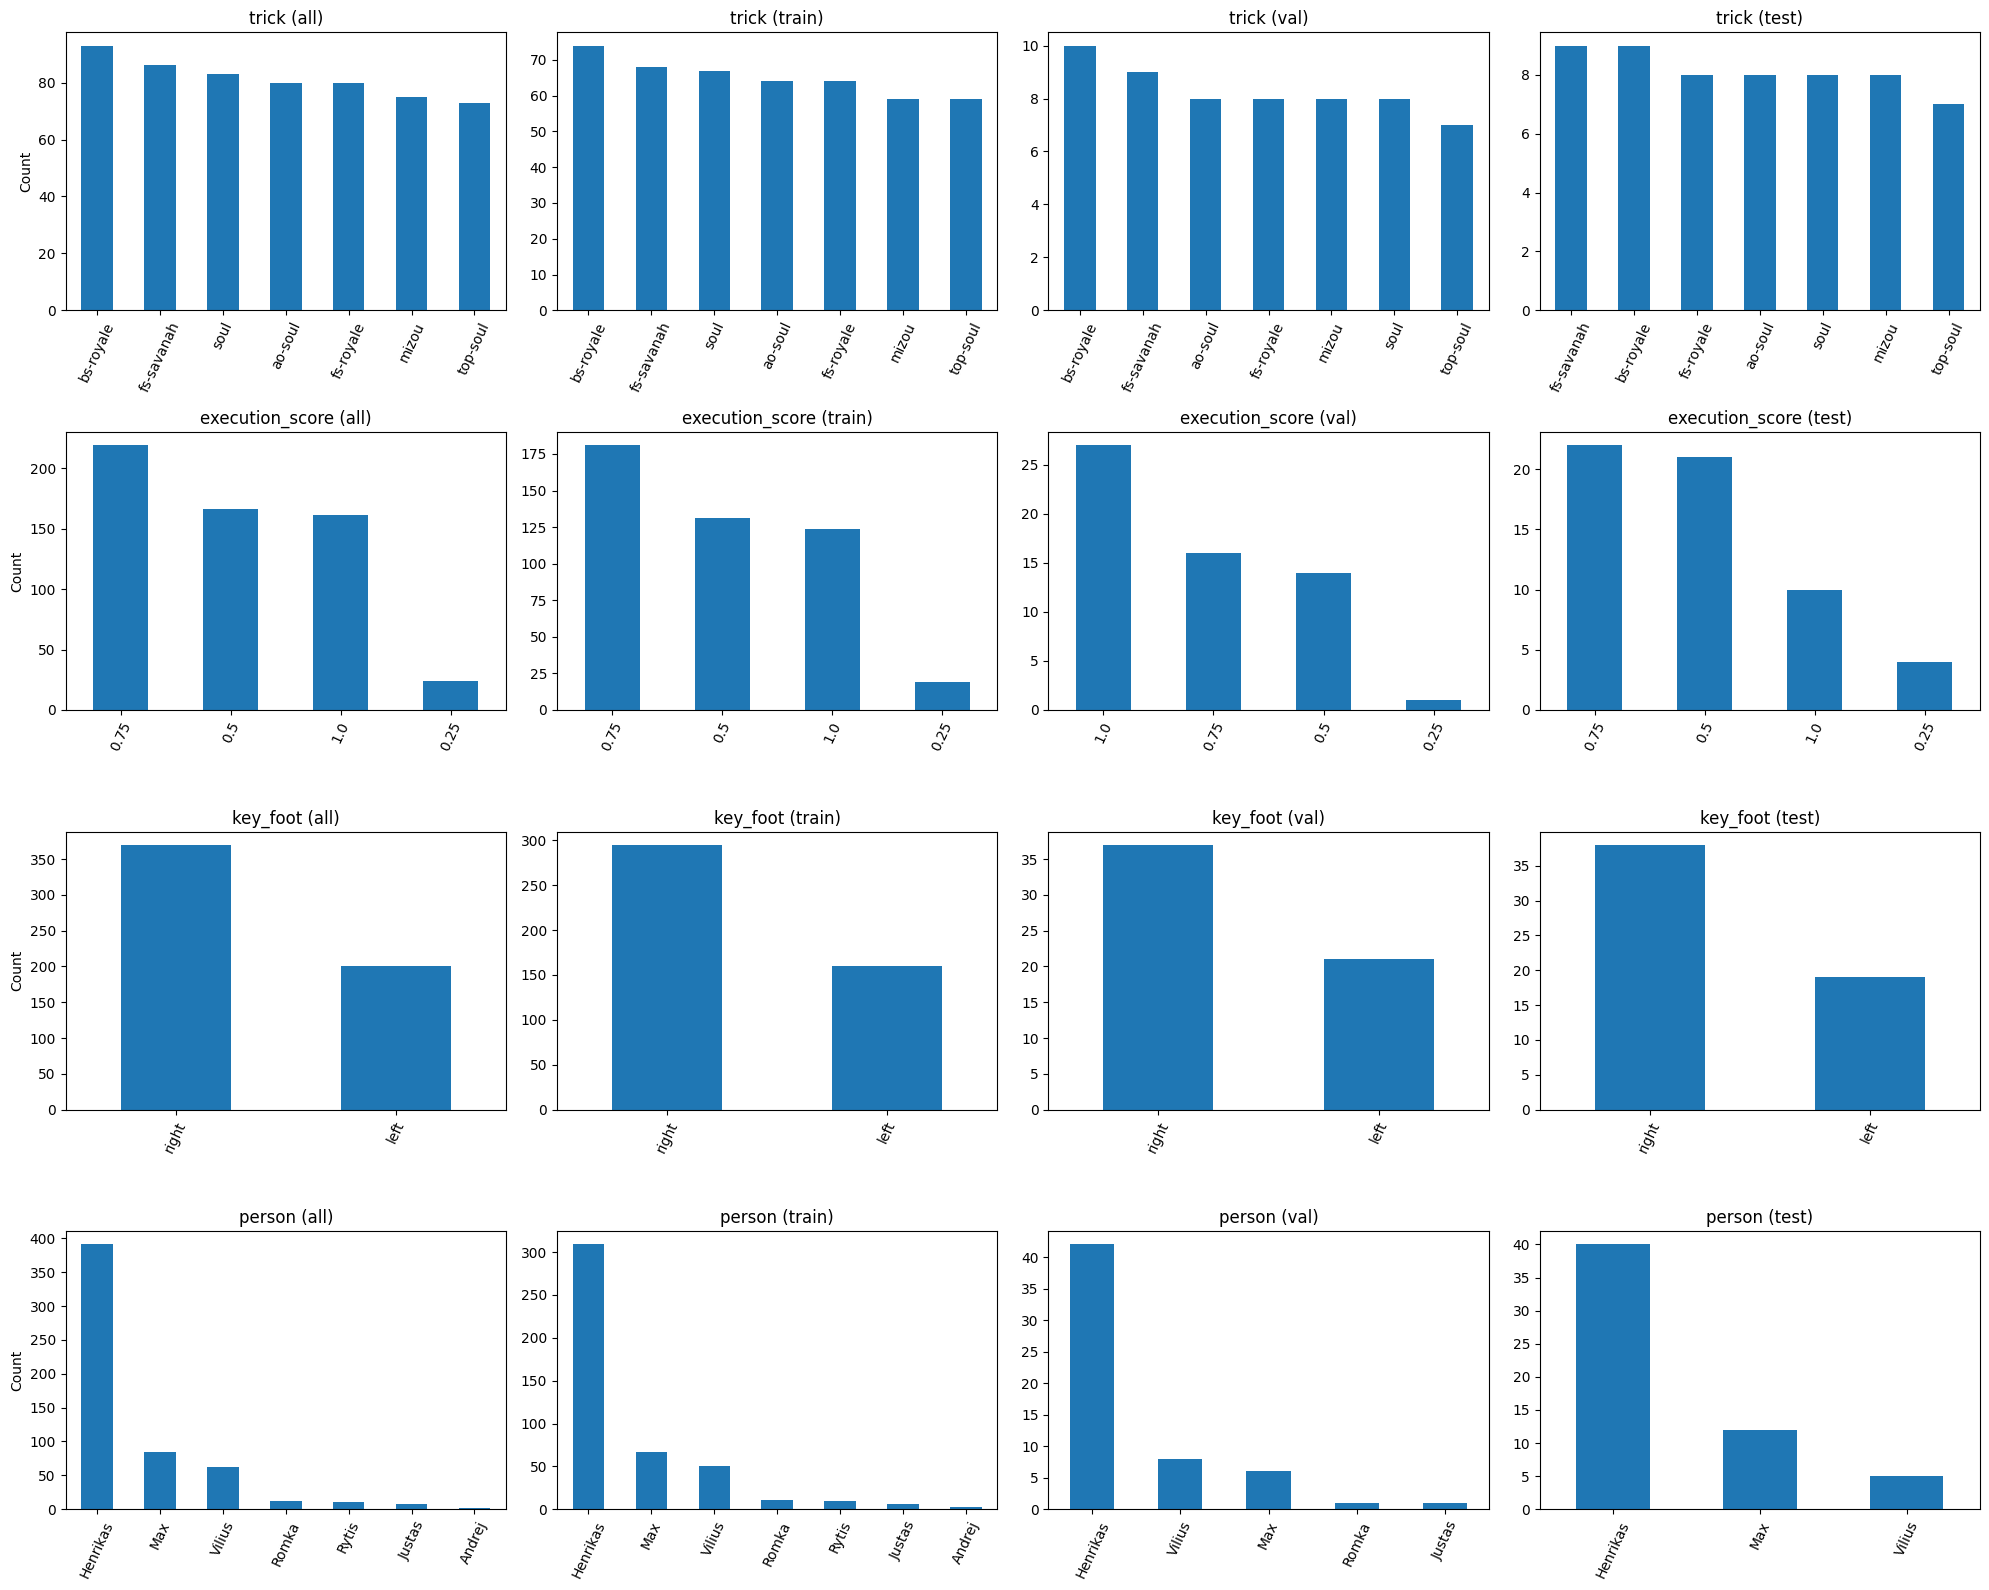

In [3]:
split_data = {"all": manifest_df}
split_data.update(split_frames)
num_cols = len(split_data)
fig, axes = plt.subplots(
    len(TRICK_TASK_COLUMNS),
    num_cols,
    figsize=(5 * num_cols, 4 * len(TRICK_TASK_COLUMNS)),
    squeeze=False,
)
for row, label_col in enumerate(TRICK_TASK_COLUMNS):
    for col_idx, (split_name, df) in enumerate(split_data.items()):
        ax = axes[row][col_idx]
        counts = df[label_col].value_counts().sort_values(ascending=False)
        counts.plot(kind="bar", ax=ax)
        ax.set_title(f"{label_col} ({split_name})")
        ax.set_xlabel("")
        ax.set_ylabel("Count" if col_idx == 0 else "")
        ax.tick_params(axis="x", rotation=65)
plt.tight_layout()
plt.show()

## Task: Score estimation


### Load manifests


In [4]:
SCORE_TASK_MANIFEST_DIR = MANIFEST_DIR / "score_prediction"
score_split_paths = {
    "train": SCORE_TASK_MANIFEST_DIR / "train.jsonl",
    "val": SCORE_TASK_MANIFEST_DIR / "val.jsonl",
    "test": SCORE_TASK_MANIFEST_DIR / "test.jsonl",
}
score_split_frames = {}
for split, path in score_split_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing manifest: {path}. Run the data pipeline first."
        )
    df = pd.read_json(path, lines=True)
    df["split"] = split
    score_split_frames[split] = df

score_manifest_df = pd.concat(score_split_frames.values(), ignore_index=True)
print("Score manifests rows per split:")
for split, df in score_split_frames.items():
    print(f"  {split}: {len(df)}")
score_manifest_df.head()

Score manifests rows per split:
  train: 455
  val: 58
  test: 57


video_id  \
0  25-10-31 19-54-19 5689-00.01.27.696-00.01.36.5...   
1  25-11-02 19-14-55 5695-00.06.08.586-00.06.12.8...   
2  25-10-31 19-46-26 5688-00.05.46.116-00.05.50.9...   
3  25-11-02 19-14-55 5695-00.08.45.991-00.08.51.0...   
4  25-11-15 18-42-16 5731-00.08.26.303-00.08.30.2...   

                                             s3_path  execution_score  \
0  s3://aitraf/clips/25-10-31 19-54-19 5689-00.01...             0.50   
1  s3://aitraf/clips/25-11-02 19-14-55 5695-00.06...             0.75   
2  s3://aitraf/clips/25-10-31 19-46-26 5688-00.05...             0.50   
3  s3://aitraf/clips/25-11-02 19-14-55 5695-00.08...             0.50   
4  s3://aitraf/clips/25-11-15 18-42-16 5731-00.08...             0.50   

       trick key_foot    person  \
0  fs-royale    right  Henrikas   
1    ao-soul    right     Romka   
2  fs-royale    right       Max   
3   top-soul    right     Romka   
4       soul     left       Max   

0                             Too slow and too short  train  
1              Just a bit too shy of great execution  train  
2  Looks good, just jump in too late and jump off...  train  
3      Too short, forced landing due to balance loss  train  
4                           Short and forced landing  train

### Feature distribution across splits


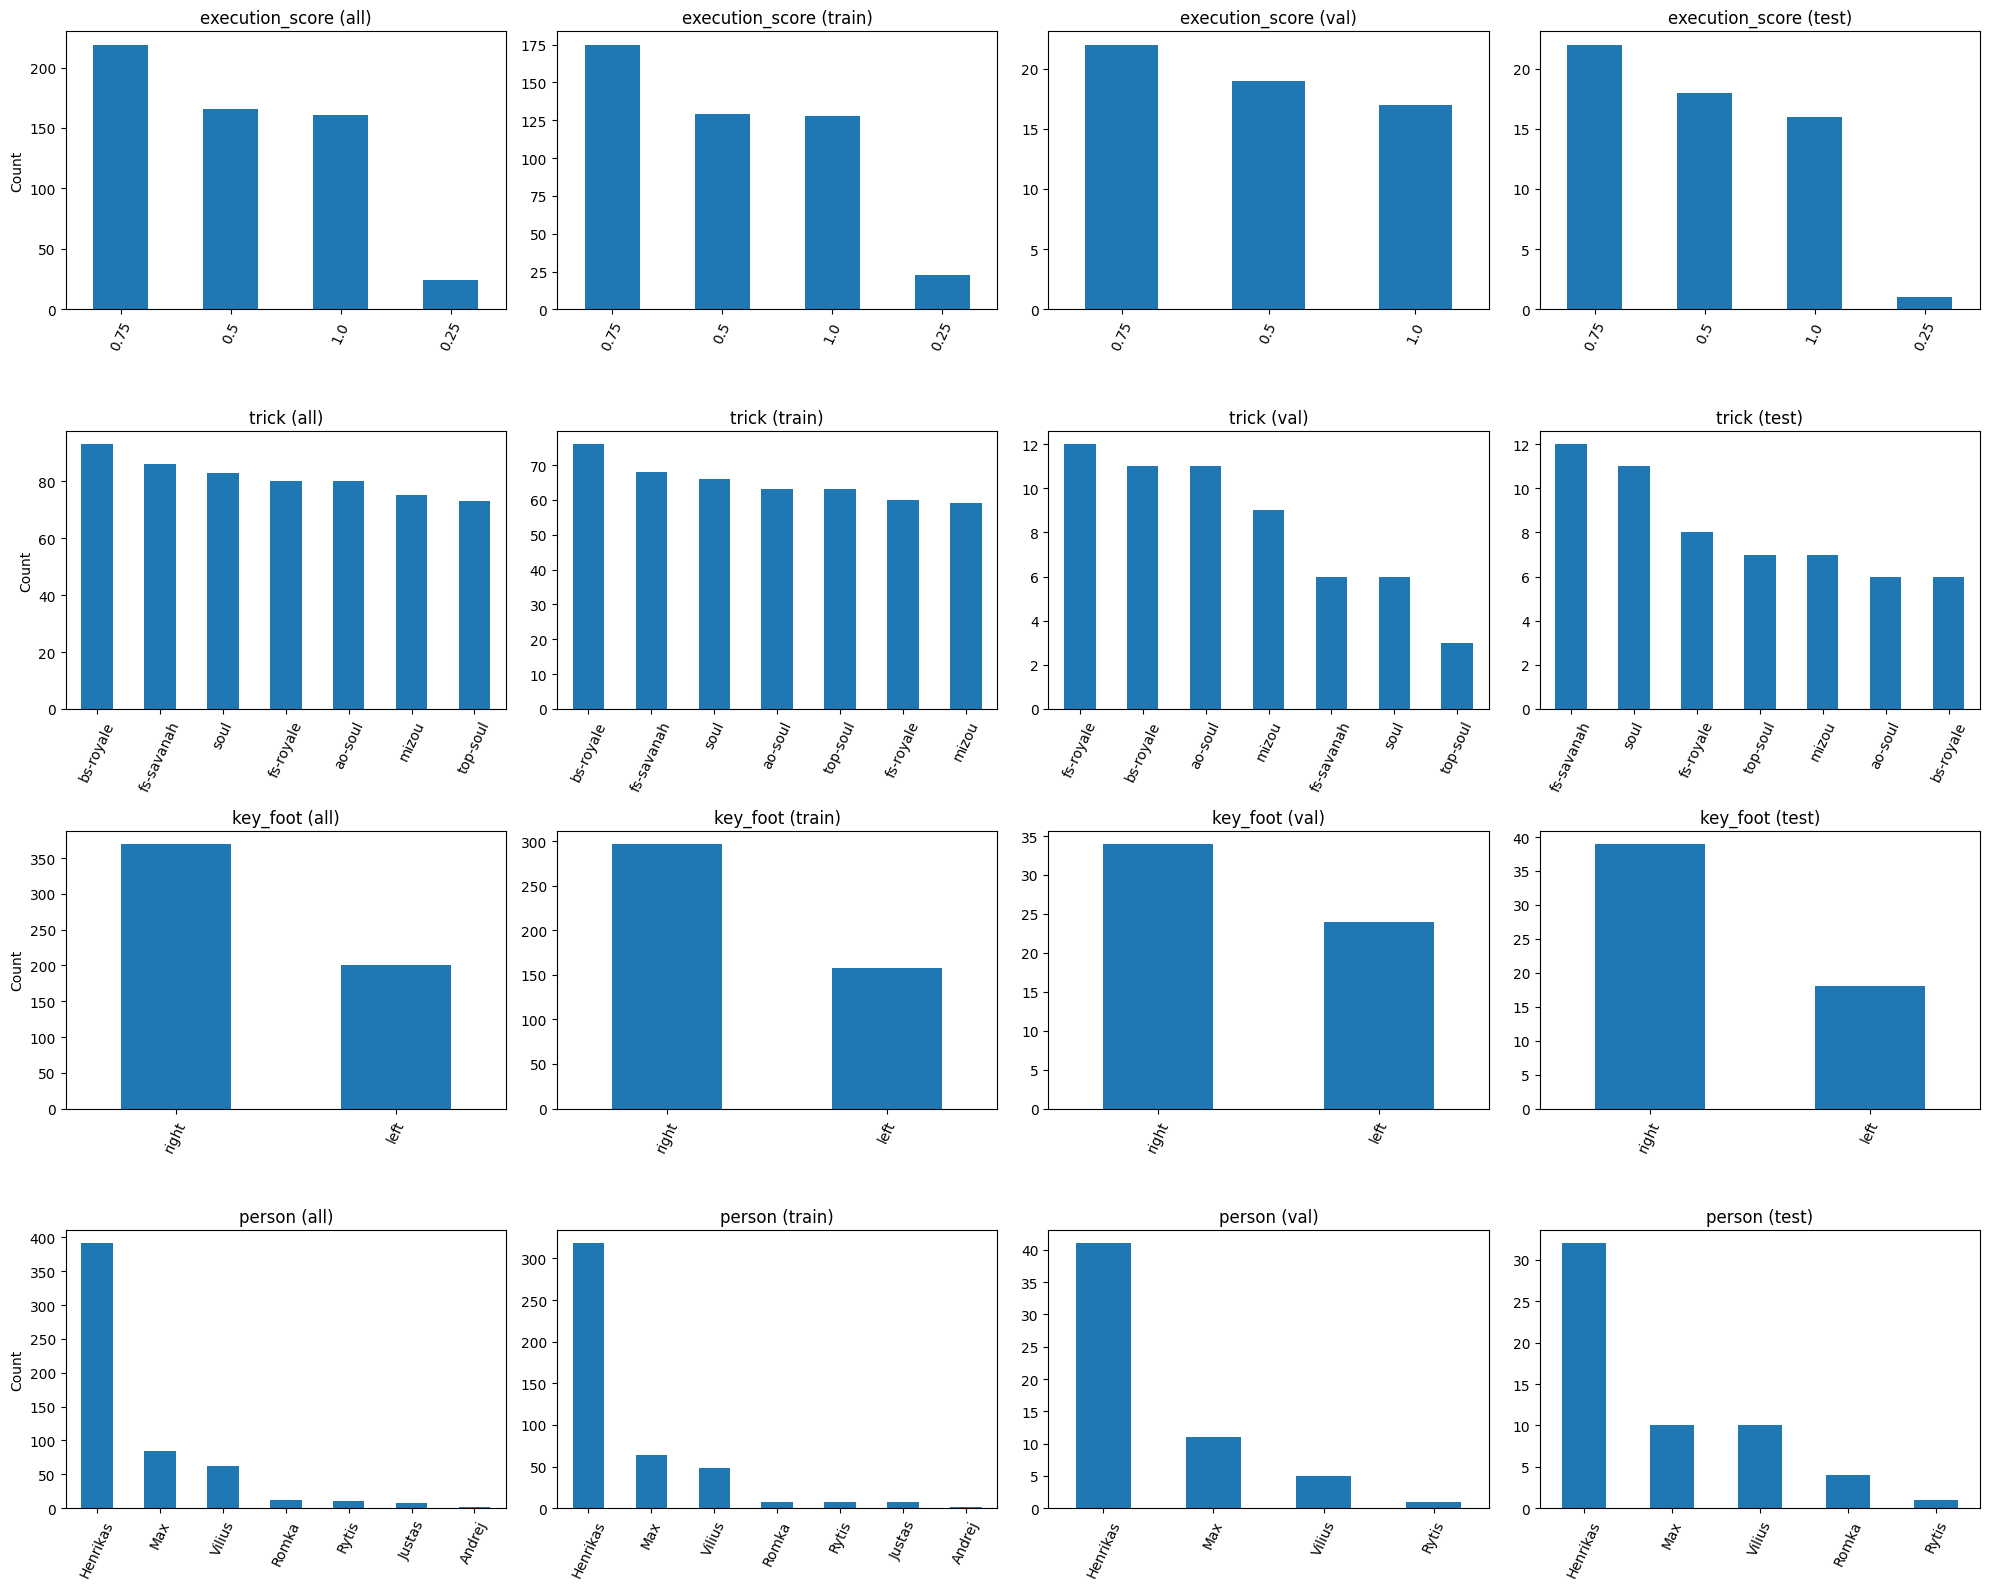

In [5]:
score_split_data = {"all": score_manifest_df}
score_split_data.update(score_split_frames)
num_cols = len(score_split_data)
fig, axes = plt.subplots(
    len(SCORE_TASK_COLUMNS),
    num_cols,
    figsize=(5 * num_cols, 4 * len(SCORE_TASK_COLUMNS)),
    squeeze=False,
)
for row, label_col in enumerate(SCORE_TASK_COLUMNS):
    for col_idx, (split_name, df) in enumerate(score_split_data.items()):
        ax = axes[row][col_idx]
        counts = df[label_col].value_counts().sort_values(ascending=False)
        counts.plot(kind="bar", ax=ax)
        ax.set_title(f"{label_col} ({split_name})")
        ax.set_xlabel("")
        ax.set_ylabel("Count" if col_idx == 0 else "")
        ax.tick_params(axis="x", rotation=65)
plt.tight_layout()
plt.show()